In [98]:
import numpy as np
import scipy.stats as scs
import seaborn as sns
import matplotlib.pyplot as plt


In [99]:
n_val = [20, 60, 100]


distributions = {
    "Normal": lambda n: scs.norm.rvs(0, 1, size=n),
    "Cauchy": lambda n: scs.cauchy.rvs(0, 1, size=n),
    "Laplace": lambda n: scs.laplace.rvs(0, scale=1/np.sqrt(2), size=n),
    "Poisson": lambda n: scs.poisson.rvs(5, size=n),
    "Uniform": lambda n: scs.uniform.rvs(-np.sqrt(3), 2*np.sqrt(3), size=n)
}

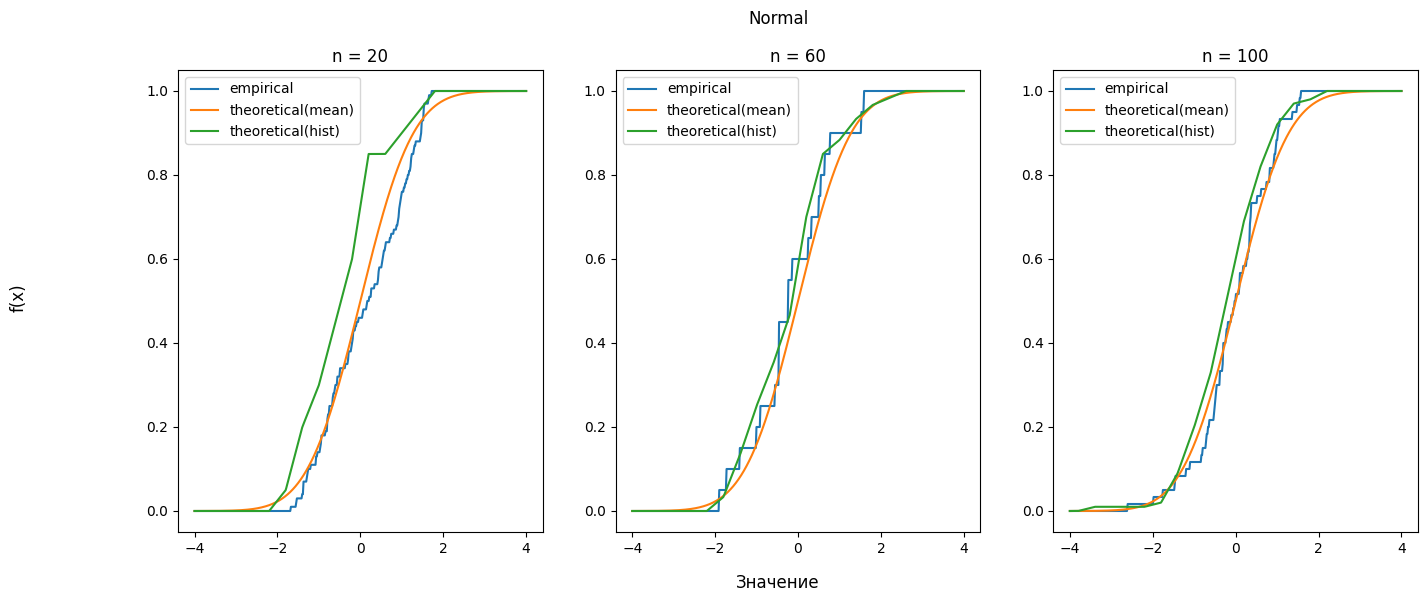

In [100]:
x = np.linspace(-4,4,500)
y_th = scs.norm.cdf(x)

# plt.plot(x, y_th)

def calculate_edf(sample, x):
    emp_cdf = []
    for i in  x:
        val = np.mean(sample <= i)
        emp_cdf.append(val)
    return emp_cdf

def calculate_edf_histogram(sample, x_grid, bins=30, x_range=None):
    """ЭФР через кумулятивную гистограмму"""
    if x_range is None:
        x_range = (sample.min(), sample.max())
    counts, bin_edges = np.histogram(sample, bins=bins, range=x_range)
    cdf_cumulative = np.cumsum(counts) / len(sample)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    cdf_interp = np.interp(x_grid, bin_centers, cdf_cumulative, left=0, right=1)
    return cdf_interp.tolist()

fig, ax = plt.subplots(1,3, figsize=(16,6))
# plt.figure(figsize=(10,8))
fig.suptitle("Normal")
fig.supxlabel("Значение")
fig.supylabel("f(x)")

for i, n in enumerate(n_val):
    ax[i].set_title(f"n = {n}")
    
    #empirical
    ax[i].plot(x, y,  label='empirical')
    
    #th mean
    y = calculate_edf(distributions['Normal'](n), x)
    ax[i].plot(x, scs.norm.cdf(x),  label='theoretical(mean)')

    #th hist 
    y_hist = calculate_edf_histogram(distributions['Normal'](n), x, bins=20, x_range=(-4, 4))
    ax[i].plot(x, y_hist, label='theoretical(hist)')
    
    ax[i].legend(loc='best')

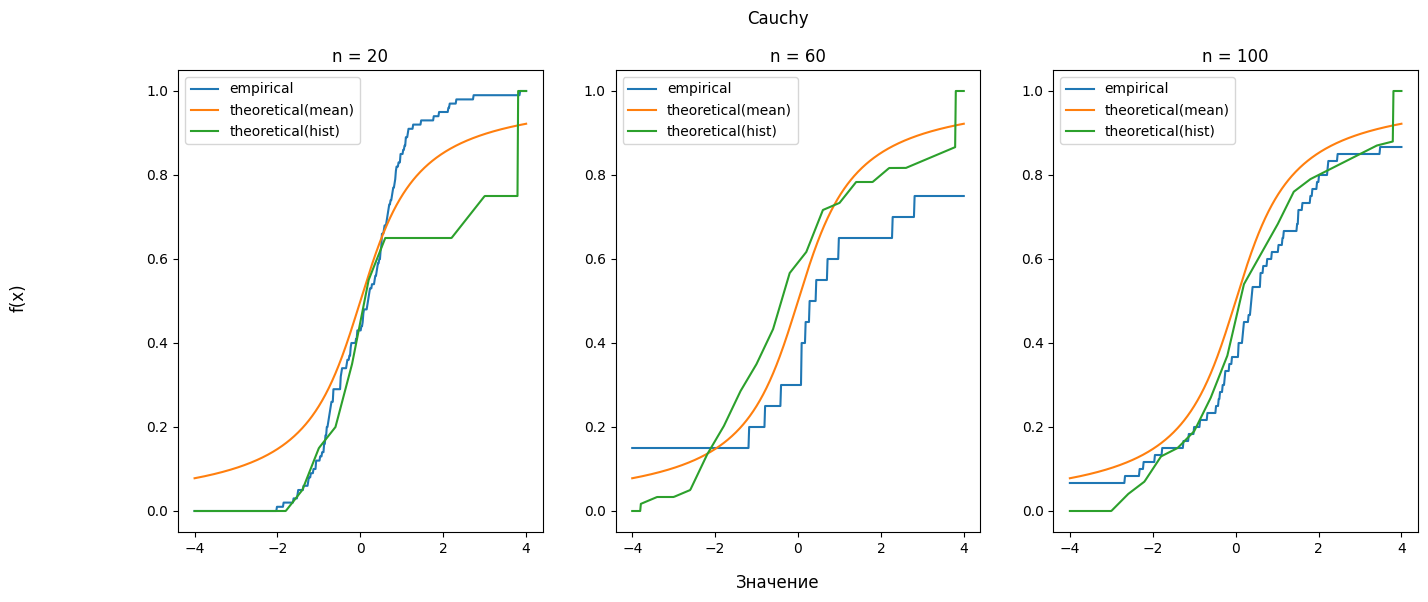

In [101]:

fig, ax = plt.subplots(1,3, figsize=(16,6))
fig.suptitle("Cauchy")
fig.supxlabel("Значение")
fig.supylabel("f(x)")

for i, n in enumerate(n_val):
    ax[i].set_title(f"n = {n}")
    
    #empirical
    ax[i].plot(x, y,  label='empirical')
    
    #th mean
    y = calculate_edf(distributions['Cauchy'](n), x)
    ax[i].plot(x, scs.cauchy.cdf(x),  label='theoretical(mean)')

    #th hist 
    y_hist = calculate_edf_histogram(distributions['Cauchy'](n), x, bins=20, x_range=(-4, 4))
    ax[i].plot(x, y_hist, label='theoretical(hist)')
    
    ax[i].legend(loc='best')

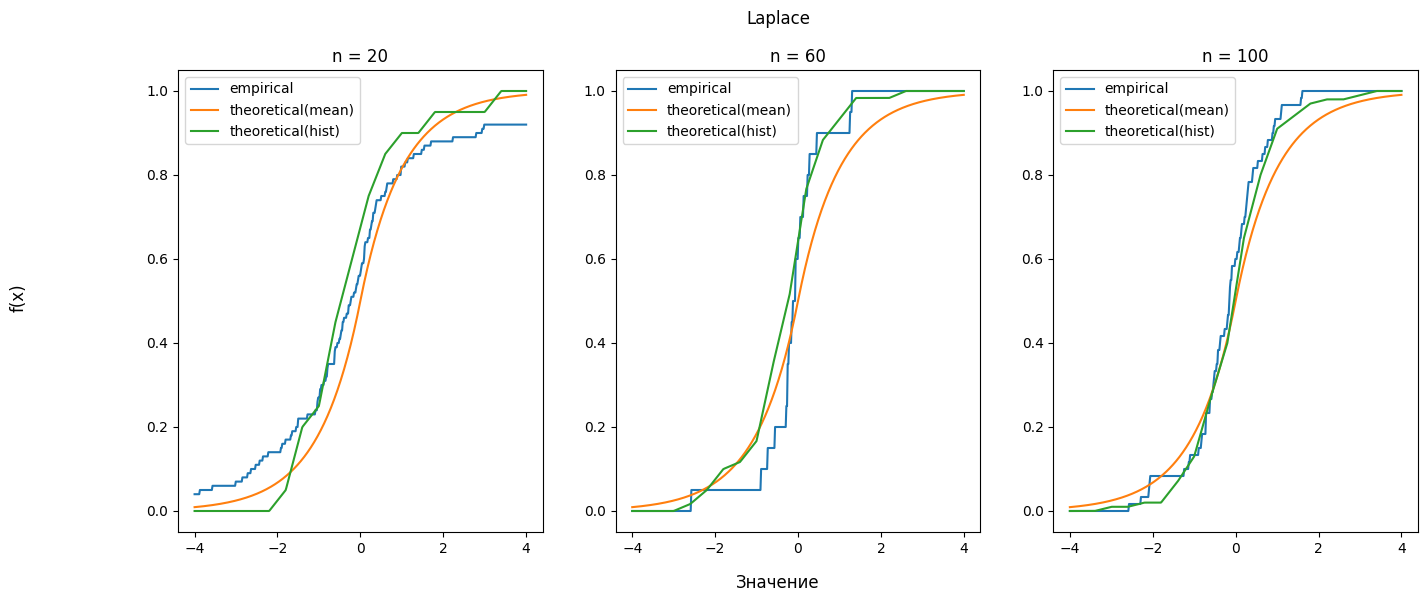

In [102]:

fig, ax = plt.subplots(1,3, figsize=(16,6))
fig.suptitle("Laplace")
fig.supxlabel("Значение")
fig.supylabel("f(x)")

for i, n in enumerate(n_val):
    ax[i].set_title(f"n = {n}")
    
    #empirical
    ax[i].plot(x, y,  label='empirical')
    
    #th mean
    y = calculate_edf(distributions['Laplace'](n), x)
    ax[i].plot(x, scs.laplace.cdf(x),  label='theoretical(mean)')

    #th hist 
    y_hist = calculate_edf_histogram(distributions['Laplace'](n), x, bins=20, x_range=(-4, 4))
    ax[i].plot(x, y_hist, label='theoretical(hist)')
    
    ax[i].legend(loc='best')

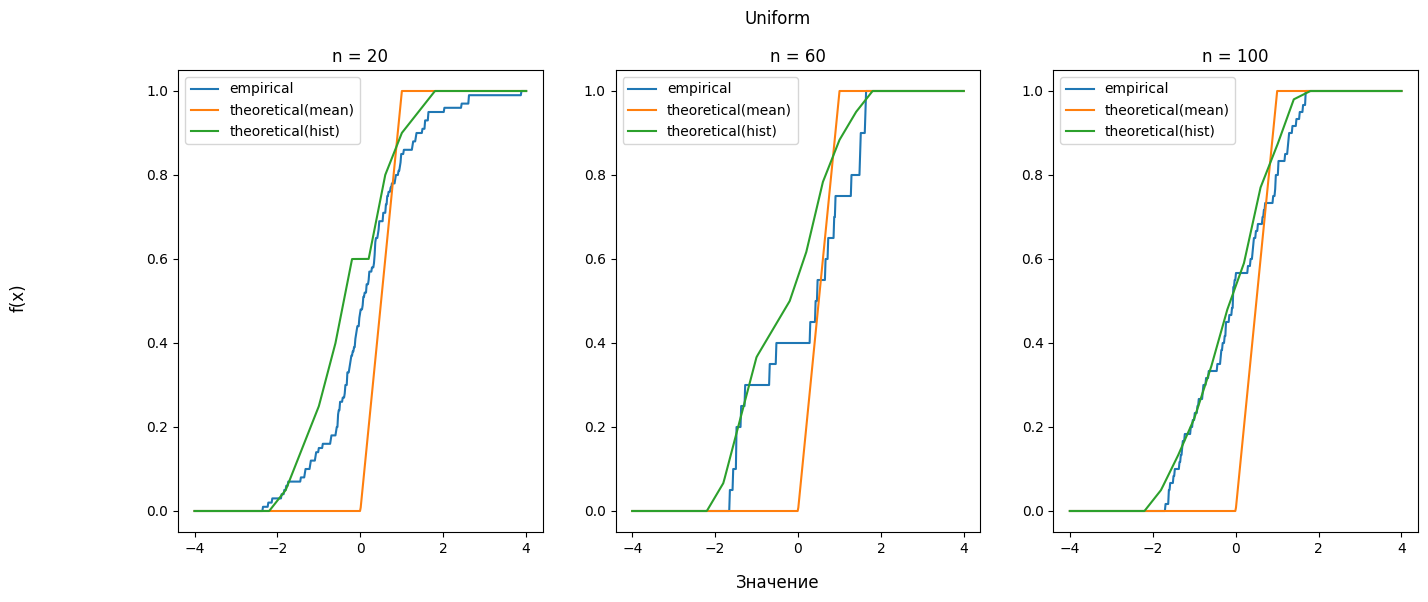

In [103]:

fig, ax = plt.subplots(1,3, figsize=(16,6))
fig.suptitle("Uniform")
fig.supxlabel("Значение")
fig.supylabel("f(x)")

for i, n in enumerate(n_val):
    ax[i].set_title(f"n = {n}")
    
    #empirical
    ax[i].plot(x, y,  label='empirical')
    
    #th mean
    y = calculate_edf(distributions['Uniform'](n), x)
    ax[i].plot(x, scs.uniform.cdf(x),  label='theoretical(mean)')

    #th hist 
    y_hist = calculate_edf_histogram(distributions['Uniform'](n), x, bins=20, x_range=(-4, 4))
    ax[i].plot(x, y_hist, label='theoretical(hist)')
    
    ax[i].legend(loc='best')

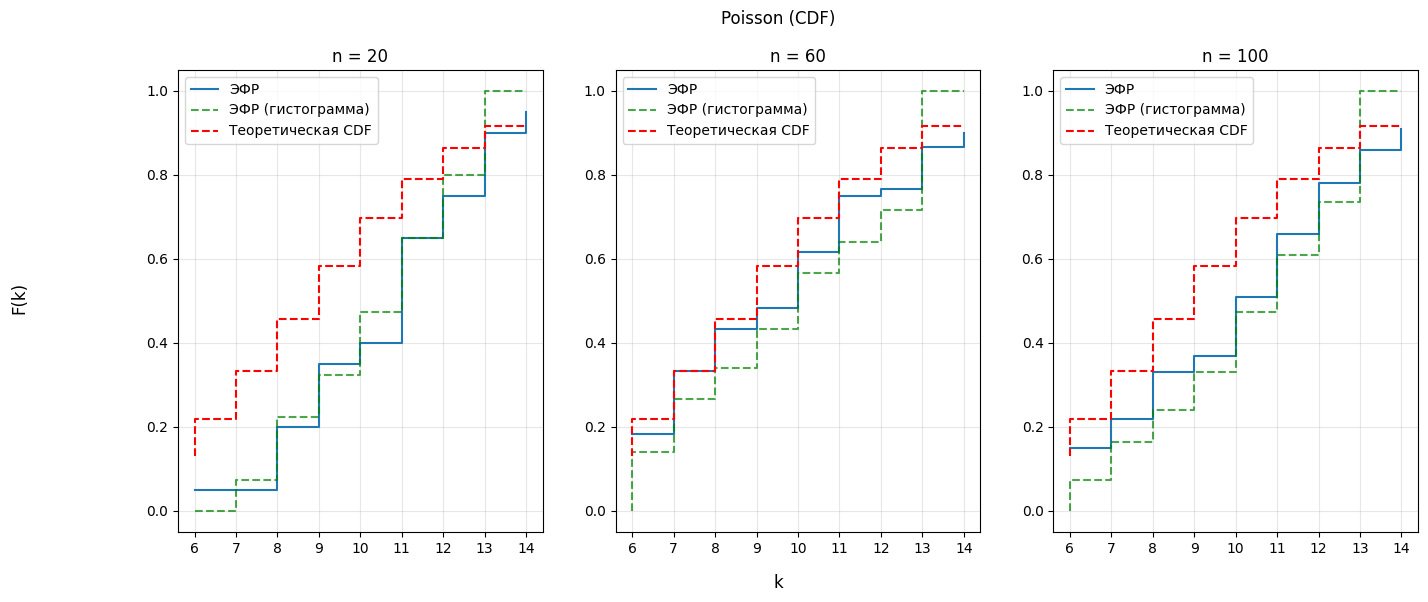

In [105]:
x_poisson = np.arange(6, 15)
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Poisson (CDF)")
fig.supxlabel("k")
fig.supylabel("F(k)")

for i, n in enumerate(n_val):
    ax[i].set_title(f"n = {n}")
    
    # Генерация выборки
    sample = np.random.poisson(lam=10, size=n)
    
    # ЭФР
    y_emp = calculate_edf(sample, x_poisson)
    ax[i].step(x_poisson, y_emp, where='post', label='ЭФР')
    

    y_hist = calculate_edf_histogram(sample, x_poisson, bins=8, x_range=(6, 14))
    ax[i].step(x_poisson, y_hist, label='ЭФР (гистограмма)', 
                color='green', linestyle='--', alpha=0.7)
    # Теоретическая CDF
    y_theo = scs.poisson.cdf(x_poisson, mu=10)
    ax[i].step(x_poisson, y_theo, 'r--', label='Теоретическая CDF')
    
    ax[i].legend(loc='best')
    ax[i].grid(True, alpha=0.3)
    ax[i].set_xticks(x_poisson)

# plt.tight

In [106]:
def gaussian_kernel(u):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

def calculate_kde(sample, x_grid, h=None):
    n = len(sample)
    
    if h is None:
        sigma = np.std(sample)
        h = 1.06 * sigma * (n ** (-0.2))
    
    kde_values = []
    for x in x_grid:
        total = sum(gaussian_kernel((x - Xi) / h) for Xi in sample)
        kde_values.append(total / (n * h))
    
    return kde_values


def calculate_density_histogram(sample, x_grid, bins=20, x_range=None):
    if x_range is None:
        x_range = (sample.min(), sample.max())
    
    counts, bin_edges = np.histogram(sample, bins=bins, range=x_range, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    density_interp = np.interp(x_grid, bin_centers, counts, left=0, right=0)
    
    return density_interp.tolist()


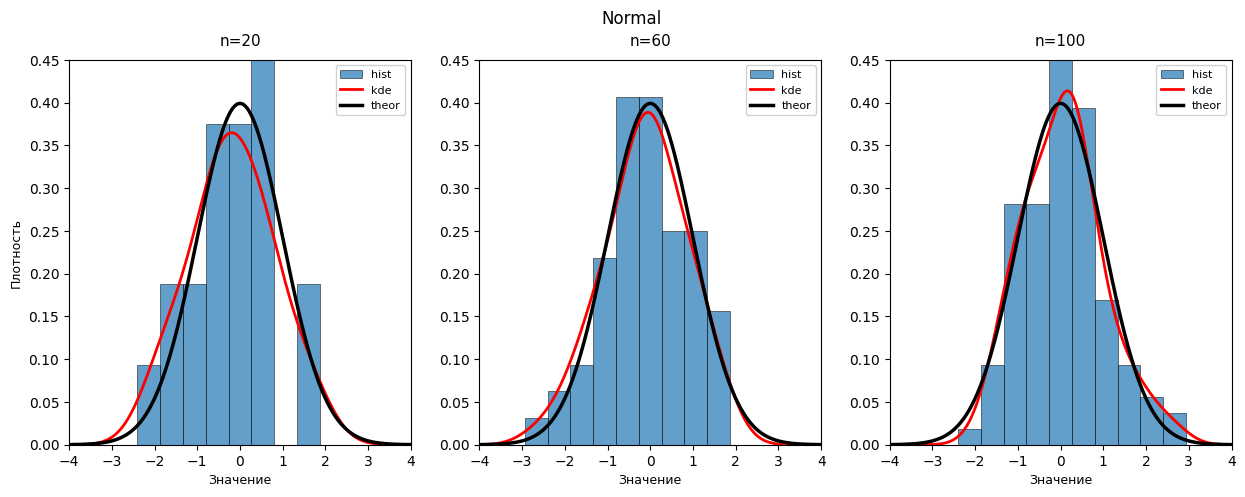

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scs

x = np.linspace(-4, 4, 500)

def gaussian_kernel(u):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

def calculate_kde(sample, x_grid, h=None):
    n = len(sample)
    if h is None:
        sigma = np.std(sample, ddof=1) 
        h = 1.06 * sigma * (n ** (-0.2))
    
    kde_values = []
    for x in x_grid:
        total = sum(gaussian_kernel((x - Xi) / h) for Xi in sample)
        kde_values.append(total / (n * h))
    return kde_values

np.random.seed(42)  
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Normal')

for i, n in enumerate(n_val):
    ax = axes[i]
    sample = distributions['Normal'](n)
    
    counts, bins, patches = ax.hist(sample, bins=15, range=(-4, 4), 
                                     density=True, alpha=0.7, 
                                     edgecolor='black', 
                                     linewidth=0.5, label='hist')
    
    y_kde = calculate_kde(sample, x)
    ax.plot(x, y_kde, color='red', linewidth=2, label='kde')
    
    y_theo = scs.norm.pdf(x, loc=0, scale=1)
    ax.plot(x, y_theo, color='black', linewidth=2.5, label='theor')
    
    ax.set_title(f'n={n}', fontsize=11, pad=10)
    ax.set_xlabel('Значение', fontsize=9)
    if i == 0:
        ax.set_ylabel('Плотность', fontsize=9)
    
    ax.legend(loc='best', fontsize=8, framealpha=0.9)
    
    ax.set_xlim(-4, 4)
    ax.set_ylim(0, max(0.45, max(y_theo) * 1.1))

plt.show()

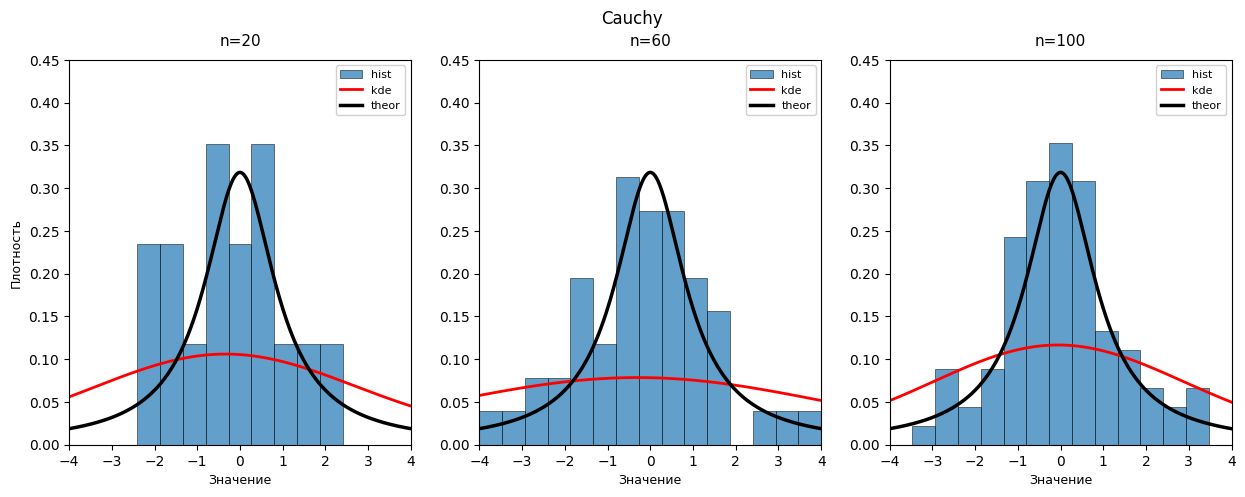

In [ ]:
np.random.seed(42)  
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Cauchy')

for i, n in enumerate(n_val):
    ax = axes[i]
    sample = distributions['Cauchy'](n)
    
    counts, bins, patches = ax.hist(sample, bins=15, range=(-4, 4), 
                                     density=True, alpha=0.7, 
                                     edgecolor='black', 
                                     linewidth=0.5, label='hist')
    
    y_kde = calculate_kde(sample, x)
    ax.plot(x, y_kde, color='red', linewidth=2, label='kde')
    
    y_theo = scs.cauchy.pdf(x, loc=0, scale=1)
    ax.plot(x, y_theo, color='black', linewidth=2.5, label='theor')
    
    ax.set_title(f'n={n}', fontsize=11, pad=10)
    ax.set_xlabel('Значение', fontsize=9)
    if i == 0:
        ax.set_ylabel('Плотность', fontsize=9)
    
    ax.legend(loc='best', fontsize=8, framealpha=0.9)
    
    ax.set_xlim(-4, 4)
    ax.set_ylim(0, max(0.45, max(y_theo) * 1.1))

plt.show()

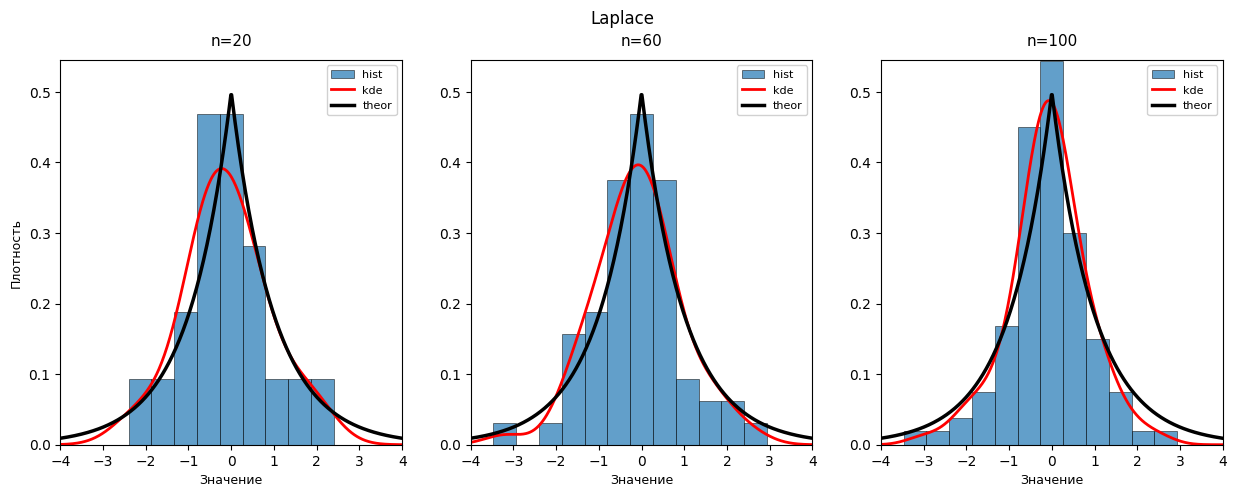

In [111]:
np.random.seed(42)  
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Laplace')

for i, n in enumerate(n_val):
    ax = axes[i]
    sample = distributions['Laplace'](n)
    
    counts, bins, patches = ax.hist(sample, bins=15, range=(-4, 4), 
                                     density=True, alpha=0.7, 
                                     edgecolor='black', 
                                     linewidth=0.5, label='hist')
    
    y_kde = calculate_kde(sample, x)
    ax.plot(x, y_kde, color='red', linewidth=2, label='kde')
    
    y_theo = scs.laplace.pdf(x, loc=0, scale=1)
    ax.plot(x, y_theo, color='black', linewidth=2.5, label='theor')
    
    ax.set_title(f'n={n}', fontsize=11, pad=10)
    ax.set_xlabel('Значение', fontsize=9)
    if i == 0:
        ax.set_ylabel('Плотность', fontsize=9)
    
    ax.legend(loc='best', fontsize=8, framealpha=0.9)
    
    ax.set_xlim(-4, 4)
    ax.set_ylim(0, max(0.45, max(y_theo) * 1.1))

plt.show()

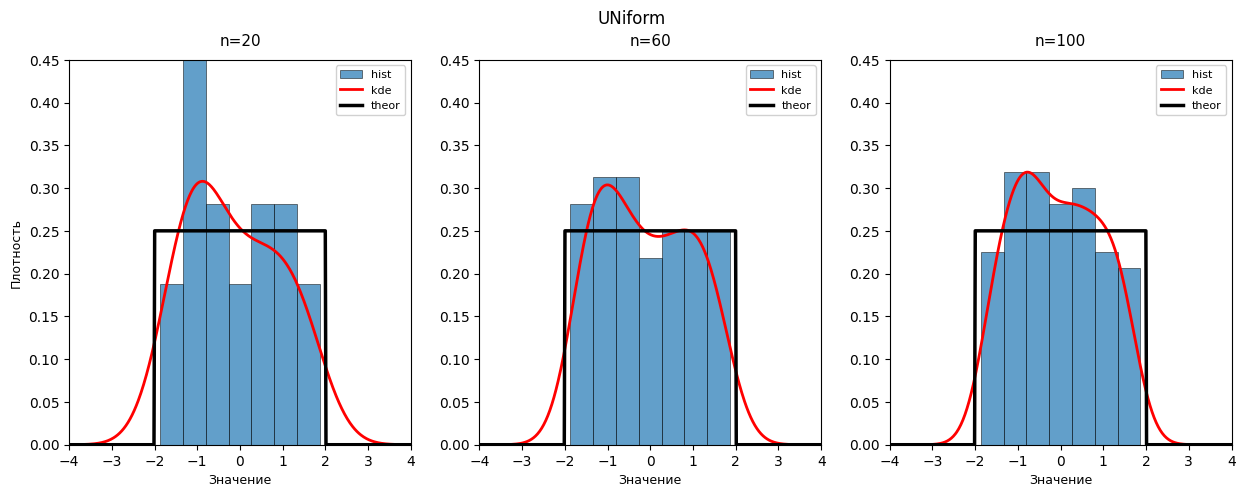

In [118]:
np.random.seed(42)  
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('UNiform')

for i, n in enumerate(n_val):
    ax = axes[i]
    sample = distributions['Uniform'](n)
    
    counts, bins, patches = ax.hist(sample, bins=15, range=(-4, 4), 
                                     density=True, alpha=0.7, 
                                     edgecolor='black', 
                                     linewidth=0.5, label='hist')
    
    y_kde = calculate_kde(sample, x)
    ax.plot(x, y_kde, color='red', linewidth=2, label='kde')
    
    y_theo = scs.uniform.pdf(x, loc=-2, scale=4)
    ax.plot(x, y_theo, color='black', linewidth=2.5, label='theor')
    
    ax.set_title(f'n={n}', fontsize=11, pad=10)
    ax.set_xlabel('Значение', fontsize=9)
    if i == 0:
        ax.set_ylabel('Плотность', fontsize=9)
    
    ax.legend(loc='best', fontsize=8, framealpha=0.9)
    
    ax.set_xlim(-4, 4)
    ax.set_ylim(0, max(0.45, max(y_theo) * 1.1))

plt.show()

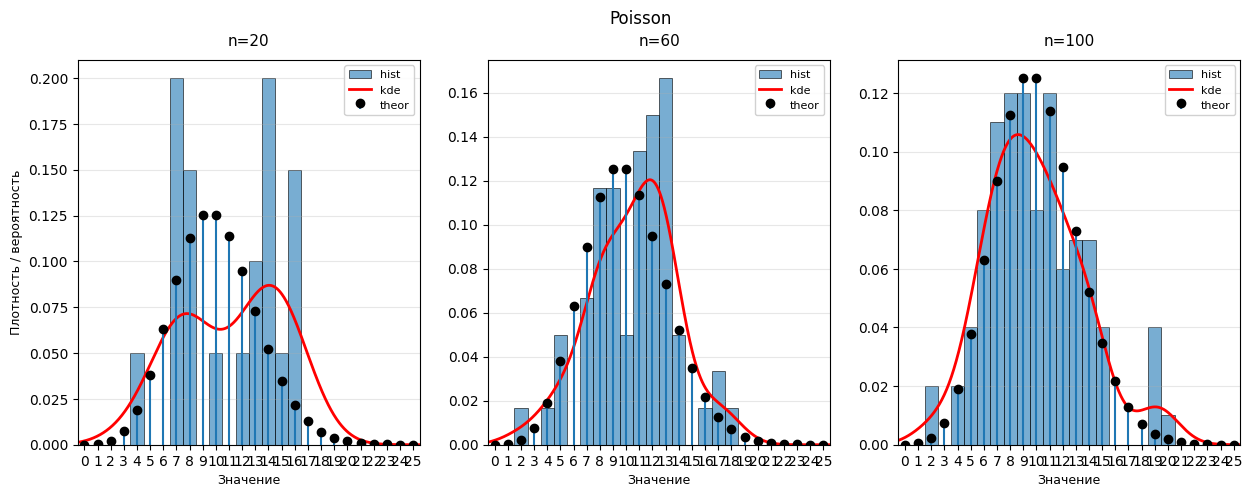

In [145]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Poisson')

for i, n in enumerate(n_val):
    ax = axes[i]
    sample = distributions['Poisson'](n)

    max_x = max(25, sample.max() + 3)
    x_grid = np.linspace(-0.5, max_x + 0.5, 1000)
    x_p = np.arange(0, max_x + 1)

    bins = np.arange(-0.5, max_x + 1.5, 1)
    ax.hist(
        sample,
        bins=bins,
        density=True,
        alpha=0.6,
        edgecolor='black',
        linewidth=0.7,
        label='hist'
    )

    y_kde = calculate_kde(sample, x_grid)
    ax.plot(x_grid, y_kde, color='red', linewidth=2, label='kde')

    y_theo = scs.poisson.pmf(x_p, mu=10)
    ax.stem(x_p, y_theo, markerfmt='ko', basefmt=' ', label='theor')

    ax.set_title(f'n={n}', fontsize=11, pad=10)
    ax.set_xlabel('Значение', fontsize=9)
    if i == 0:
        ax.set_ylabel('Плотность / вероятность', fontsize=9)

    ax.set_xlim(-0.5, max_x + 0.5)
    ax.set_xticks(np.arange(0, max_x + 1, 1))
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(loc='best', fontsize=8, framealpha=0.9)

plt.show()